In [ ]:
import osmnx as ox
import geopandas as gpd

ox.__version__

'2.0.1'

In [ ]:
G = ox.graph_from_place('Железногорск, Красноярский край, Россия', network_type='drive_service')

<Axes: >

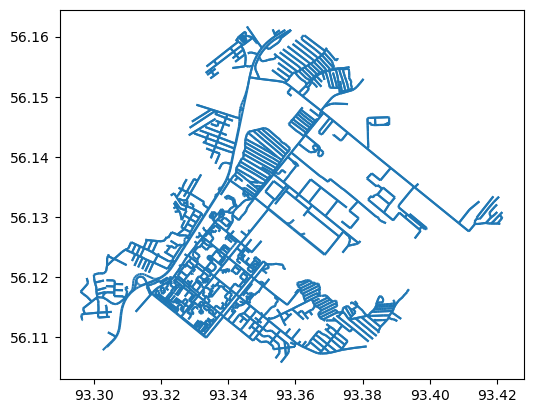

In [33]:
highways = gpd.read_file('sosnovoborsk.gpkg', layer='гдс')
highways = highways.set_crs(4326)
highways.plot()

In [34]:
highways.head(2)

,u,v,key,osmid,highway,lanes,maxspeed,oneway,ref,reversed,length,name,bridge,service,tunnel,travel_time,geometry
0,290700353,2034402247,0,111848408,secondary,2,616.67,False,04Н-374,False,213.754270,None,None,None,None,0.346627,"LINESTRING (93.35697 56.1611, 93.35403 56.1601)"
1,290700355,290700356,0,111848408,secondary,2,616.67,False,04Н-374,False,77.657296,None,None,None,None,0.125930,"LINESTRING (93.35281 56.15962, 93.35185 56.15917)"


In [27]:
import networkx as nx
from shapely.geometry import Point, LineString
from shapely.ops import unary_union
import numpy as np
from collections import defaultdict
from scipy.spatial import cKDTree
from osmnx import utils

def gdf_to_multidigraph(highways_gdf, tolerance=1e-6, oneway_column=None):
    """
    Преобразует GeoDataFrame с дорожной сетью в направленный мультиграф NetworkX.
    
    Параметры:
    -----------
    highways_gdf : GeoDataFrame
        GeoDataFrame с LineString геометриями, представляющими дорожные сегменты
    tolerance : float, optional
        Допуск для объединения близких узлов в метрах (по умолчанию 1e-6)
    oneway_column : str, optional
        Название столбца, указывающего одностороннее движение (True/False или значения типа 'yes'/'no')
        
    Возвращает:
    -----------
    G : MultiDiGraph
        Направленный мультиграф NetworkX с корректно соединенными узлами
    """
    
    # Задаем метаданные для графа
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            "crs": highways_gdf.crs
        }
    # Создаём пустой направленный мультиграф
    G = nx.MultiDiGraph(**metadata)
    
    # Извлекаем все точки начала и конца линий
    nodes_coords = []
    edge_info = []
    
    print("Извлечение узлов и рёбер из геометрии...")
    for idx, row in highways_gdf.iterrows():
        geom = row.geometry
        
        # Обрабатываем LineString
        if geom.geom_type == 'LineString':
            coords = list(geom.coords)
            if len(coords) < 2:
                continue
                
            start_point = Point(coords[0])
            end_point = Point(coords[-1])
            
            nodes_coords.append((coords[0][0], coords[0][1]))
            nodes_coords.append((coords[-1][0], coords[-1][1]))
            
            # Собираем атрибуты для ребра
            edge_attrs = {}
            for col in highways_gdf.columns:
                if col != 'geometry':
                    edge_attrs[col] = row[col]
            
            # Определяем длину сегмента
            edge_attrs['length'] = geom.length
            
            # Определяем односторонность
            if oneway_column and oneway_column in row:
                oneway_value = row[oneway_column]
                if isinstance(oneway_value, str):
                    is_oneway = oneway_value.lower() in ['yes', 'true', '1', 'forward', 'ft', 'toward']
                else:
                    is_oneway = bool(oneway_value)
            else:
                is_oneway = False
            
            edge_info.append({
                'start': coords[0],
                'end': coords[-1],
                'geometry': geom,
                'attrs': edge_attrs,
                'oneway': is_oneway
            })
        
        # Обрабатываем MultiLineString
        elif geom.geom_type == 'MultiLineString':
            for line in geom.geoms:
                coords = list(line.coords)
                if len(coords) < 2:
                    continue
                    
                nodes_coords.append((coords[0][0], coords[0][1]))
                nodes_coords.append((coords[-1][0], coords[-1][1]))
                
                edge_attrs = {}
                for col in highways_gdf.columns:
                    if col != 'geometry':
                        edge_attrs[col] = row[col]
                
                edge_attrs['length'] = line.length
                
                if oneway_column and oneway_column in row:
                    oneway_value = row[oneway_column]
                    if isinstance(oneway_value, str):
                        is_oneway = oneway_value.lower() in ['yes', 'true', '1', 'forward', 'ft', 'toward']
                    else:
                        is_oneway = bool(oneway_value)
                else:
                    is_oneway = False
                
                edge_info.append({
                    'start': coords[0],
                    'end': coords[-1],
                    'geometry': line,
                    'attrs': edge_attrs,
                    'oneway': is_oneway
                })
    
    if not nodes_coords:
        print("Ошибка: не найдено узлов в данных")
        return G
    
    # Объединяем близкие узлы
    print(f"Объединение близких узлов (допуск: {tolerance})...")
    nodes_array = np.array(nodes_coords)
    
    # Используем KD-дерево для быстрого поиска близких точек
    tree = cKDTree(nodes_array)
    
    # Находим все пары близких точек
    pairs = tree.query_pairs(tolerance)
    
    # Создаём словарь для объединения узлов (Union-Find структура)
    node_mapping = {i: i for i in range(len(nodes_array))}
    
    # Объединяем близкие узлы через union-find структуру
    def find(x):
        if node_mapping[x] != x:
            node_mapping[x] = find(node_mapping[x])
        return node_mapping[x]
    
    def union(x, y):
        root_x = find(x)
        root_y = find(y)
        if root_x != root_y:
            # Всегда присваиваем меньшему индексу
            if root_x < root_y:
                node_mapping[root_y] = root_x
            else:
                node_mapping[root_x] = root_y
    
    # Объединяем все пары близких узлов
    for i, j in pairs:
        union(i, j)
    
    # Нормализуем mapping - все узлы указывают на своего представителя
    for i in range(len(nodes_array)):
        node_mapping[i] = find(i)
    
    # Создаём уникальные узлы
    unique_nodes = {}
    node_id_counter = 0
    
    for i, coords in enumerate(nodes_coords):
        representative = node_mapping[i]
        if representative not in unique_nodes:
            unique_nodes[representative] = node_id_counter
            node_id_counter += 1
    
    # Добавляем узлы в граф
    print("Добавление узлов в граф...")
    for i, coords in enumerate(nodes_coords):
        representative = node_mapping[i]
        node_id = unique_nodes[representative]
        
        if node_id not in G.nodes:
            G.add_node(node_id, x=coords[0], y=coords[1])
    
    # Создаём обратное отображение координат на индексы для быстрого поиска
    coords_to_idx = {}
    for i, coords in enumerate(nodes_coords):
        if coords not in coords_to_idx:
            coords_to_idx[coords] = []
        coords_to_idx[coords].append(i)
    
    # Добавляем рёбра
    print("Добавление рёбер в граф...")
    edges_added = 0
    
    for edge in edge_info:
        start_coords = edge['start']
        end_coords = edge['end']
        
        # Находим индексы узлов через словарь
        if start_coords not in coords_to_idx or end_coords not in coords_to_idx:
            continue
        
        # Берем первый индекс из списка (все близкие узлы уже объединены)
        start_idx = coords_to_idx[start_coords][0]
        end_idx = coords_to_idx[end_coords][0]
        
        # Получаем ID узлов через mapping
        start_rep = node_mapping[start_idx]
        end_rep = node_mapping[end_idx]
        
        start_node_id = unique_nodes[start_rep]
        end_node_id = unique_nodes[end_rep]
        
        if start_node_id == end_node_id:
            continue  # Пропускаем самопетли (если требуется, можно добавить)
        
        # Добавляем ребро в направлении движения
        edge_attrs = edge['attrs'].copy()
        edge_attrs['geometry'] = edge['geometry']
        
        G.add_edge(start_node_id, end_node_id, **edge_attrs)
        edges_added += 1
        
        # Если дорога не односторонняя, добавляем обратное ребро
        if not edge['oneway']:
            G.add_edge(end_node_id, start_node_id, **edge_attrs)
            edges_added += 1
    
    print(f"Граф создан: {len(G.nodes)} узлов, {len(G.edges)} рёбер")
    
    # Проверка связности
    if nx.is_strongly_connected(G):
        print("✓ Граф является сильно связным")
    else:
        print("⚠ Граф не является сильно связным (есть несвязанные компоненты)")
        components = list(nx.strongly_connected_components(G))
        print(f"  Количество компонент связности: {len(components)}")
        largest_component = max(components, key=len)
        print(f"  Размер наибольшей компоненты: {len(largest_component)} узлов")
        
        # Если граф не связный, можно использовать только наибольшую компоненту
        if len(components) > 1:
            print("  Рекомендация: использовать наибольшую компоненту для расчетов")
    
    return G


Извлечение узлов и рёбер из геометрии...
Объединение близких узлов (допуск: 1e-05)...
Добавление узлов в граф...
Добавление рёбер в граф...
Граф создан: 3344 узлов, 7350 рёбер
✓ Граф является сильно связным


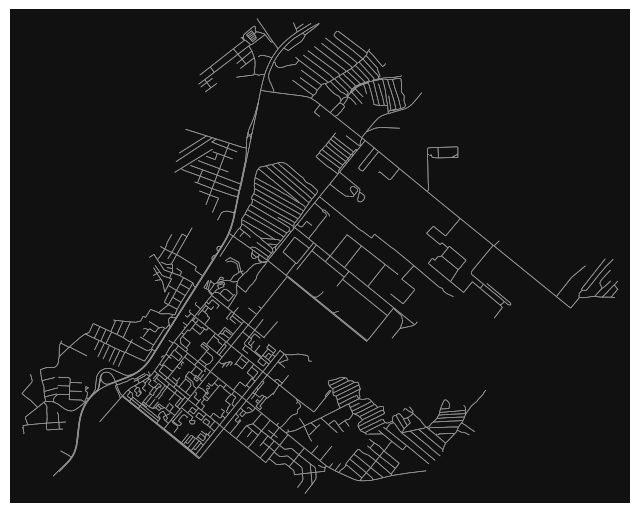

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# Пример использования функции
# Если у вас есть столбец с информацией об односторонности, укажите его название
# Например: oneway_column='oneway' или oneway_column='направление'

G = gdf_to_multidigraph(highways, tolerance=0.00001, oneway_column=None)
ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

<Axes: >

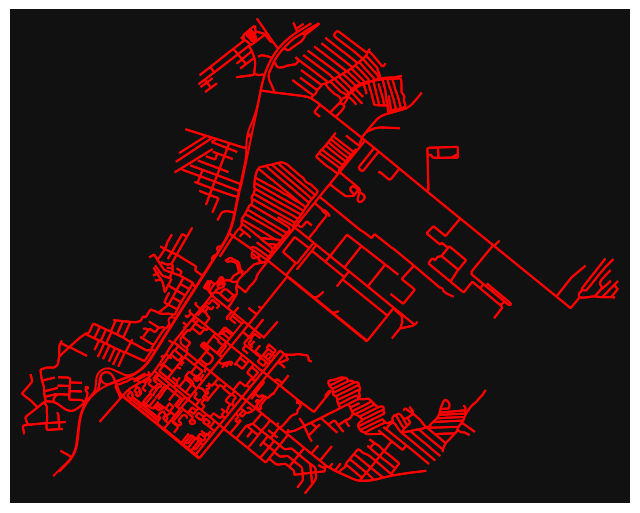

In [37]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, show=False, close=False)
highways.plot(ax=ax, color='red')

In [38]:
# Проверка работы графа: поиск кратчайшего пути
if len(G.nodes) > 0:
    nodes_list = list(G.nodes())
    
    # Выбираем два случайных узла для тестирования
    if len(nodes_list) >= 2:
        source = nodes_list[0]
        target = nodes_list[100]
        
        try:
            # Поиск кратчайшего пути по длине
            path = nx.shortest_path(G, source, target, weight='length')
            path_length = nx.shortest_path_length(G, source, target, weight='length')
            
            print(f"✓ Найден путь между узлами {source} и {target}")
            print(f"  Количество узлов в пути: {len(path)}")
            print(f"  Длина пути: {path_length:.2f} метров")
            print(f"  Узлы пути: {path[:5]}...{path[-5:]}")
        except nx.NetworkXNoPath:
            print(f"⚠ Путь между узлами {source} и {target} не найден")
        except Exception as e:
            print(f"⚠ Ошибка при поиске пути: {e}")
    else:
        print("⚠ Недостаточно узлов для тестирования")


✓ Найден путь между узлами 0 и 100
  Количество узлов в пути: 66
  Длина пути: 0.06 метров
  Узлы пути: [0, 1, 2, 3, 4]...[2296, 2291, 101, 98, 100]


In [39]:
# Функция для получения наибольшей связной компоненты
def get_largest_component(G):
    """
    Извлекает наибольшую сильно связную компоненту из графа.
    
    Параметры:
    -----------
    G : MultiDiGraph
        Направленный мультиграф NetworkX
        
    Возвращает:
    -----------
    G_largest : MultiDiGraph
        Подграф, содержащий только наибольшую компоненту
    """
    if nx.is_strongly_connected(G):
        print("Граф уже является связным")
        return G
    
    components = list(nx.strongly_connected_components(G))
    largest_component = max(components, key=len)
    
    print(f"Извлечение наибольшей компоненты: {len(largest_component)} узлов из {len(G.nodes)}")
    
    G_largest = G.subgraph(largest_component).copy()

    # Прокидываем графовые атрибуты (в т.ч. CRS)
    try:
        G_largest.graph.update(G.graph)
    except Exception:
        pass
    
    print(f"Результат: {len(G_largest.nodes)} узлов, {len(G_largest.edges)} рёбер")
    
    return G_largest

# Если граф не связный, можно использовать только наибольшую компоненту
# G_connected = get_largest_component(G)

gg = get_largest_component(G)
print(gg.number_of_nodes(), gg.number_of_edges())

Граф уже является связным
3344 7350


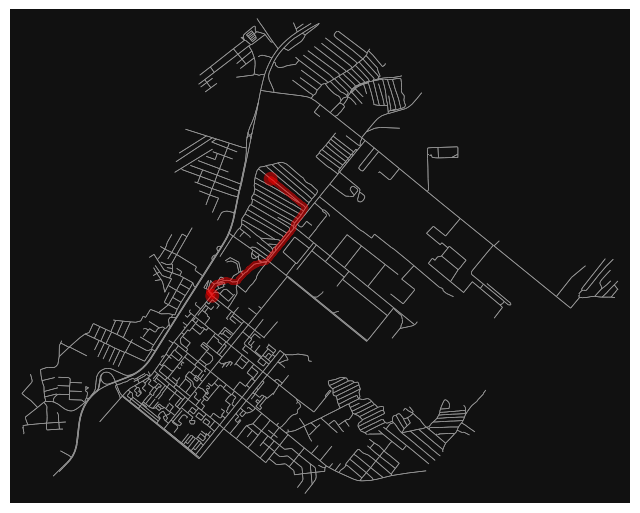

In [41]:
route = ox.shortest_path(G, 100, 1000, weight='length')
fig, ax = ox.plot_graph_route(G, route, node_size=0, edge_linewidth=0.5)

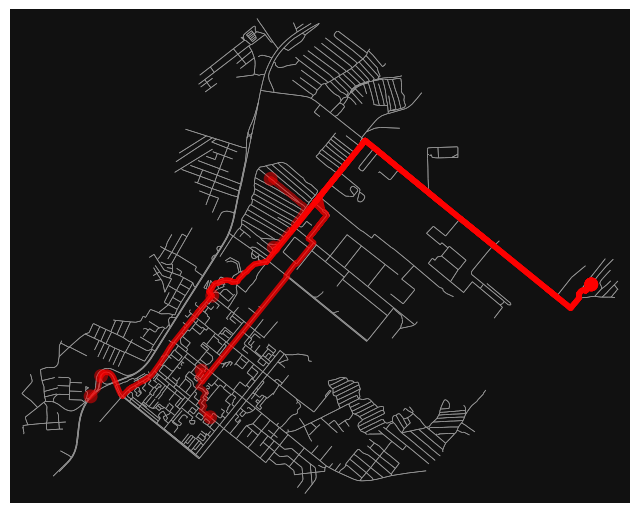

In [46]:
target_nodes = [100, 200, 500, 600, 700, 800, 1000]

routes = []

for node in target_nodes:
    route = ox.shortest_path(G, 2000, node, weight='length')
    routes.append(route)
    
fig, ax = ox.plot_graph_routes(G, routes,
    node_size=0, edge_linewidth=0.5,
    route_color='red',
    route_linewidth=1)